# 03 — Implementación del modelo base con LightGBM

## Detección de fraude en establecimientos de hospedaje

Este notebook desarrolla la **Parte 3: Implementación del modelo base** del proyecto. El objetivo es construir una primera línea base con LightGBM para detectar transacciones fraudulentas, especialmente en el contexto de establecimientos de hospedaje.

Esta etapa solicita:

- Entrenar un modelo inicial con **LightGBM**.
- Evaluar el rendimiento con métricas tradicionales como **AUC-ROC** y **F1-score**.
- Analizar el desempeño inicial en términos de **fraude detectado** y **falsos positivos**.



## 1. Importación de librerías y configuración inicial

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 22

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

# Detección automática de la raíz del proyecto.
# Esto permite ejecutar el notebook desde /notebooks o desde la raíz del repositorio.
current_dir = Path.cwd()

if (current_dir / "data" / "processed").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "data" / "processed").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "No se encontró la carpeta data/processed. "
        "Verifica que el notebook esté dentro del repositorio del proyecto."
    )

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "01_bo_vip_seed22_n100000.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datos procesados: {DATA_PROCESSED}")
print(f"Resultados: {RESULTS_DIR}")


Raíz del proyecto: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI
Datos procesados: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/data/processed
Resultados: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/results


## 2. Carga de datos

De acuerdo con la descripción del proyecto, el mes de **junio de 2025** se utiliza como conjunto de evaluación. Por eso, el flujo principal del notebook carga los archivos generados en la etapa de ingeniería de variables:

- `train_features.csv`: transacciones históricas previas a junio.
- `test_features_june.csv`: transacciones del mes de junio para evaluación final.


In [2]:
train_path = DATA_PROCESSED / "train_features.csv"
test_path = DATA_PROCESSED / "test_features_june.csv"

if train_path.exists() and test_path.exists():
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    source = "features"
    print("Se cargaron train_features.csv y test_features_june.csv")
else:
    print("No se encontraron archivos processed. Se cargará el CSV raw y se generarán features mínimas.")
    df = pd.read_csv(DATA_RAW, sep=";")

    # Parseo de fecha usado en el EDA: DE7 viene como MMDDHHMMSS sin año explícito.
    df["transaction_datetime"] = pd.to_datetime(
        df["DE7_transmission_datetime"].astype(str).str.zfill(10),
        format="%m%d%H%M%S",
        errors="coerce"
    )
    df["transaction_month"] = df["transaction_datetime"].dt.month
    df["transaction_day"] = df["transaction_datetime"].dt.day

    # Features base alineadas al enfoque de hospedaje.
    df["is_hotel"] = df["DE18_merchant_category_code"].eq(7011)
    df["amount_vs_baseline"] = df["amount_usd"] - df["client_baseline_amount"]
    df["amount_baseline_ratio"] = np.where(
        df["client_baseline_amount"] > 0,
        df["amount_usd"] / df["client_baseline_amount"],
        np.nan
    )
    df["hotel_international"] = df["is_hotel"] & df["is_international"].astype(bool)
    df["hotel_high_distance"] = df["is_hotel"] & (
        df["distance_from_home_km"] > df["distance_from_home_km"].quantile(0.75)
    )

    train_df = df[df["transaction_month"] < 6].copy()
    test_df = df[df["transaction_month"] == 6].copy()
    source = "raw_minimal_features"

print(f"Fuente utilizada: {source}")
print(f"Train: {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas")
print(f"Test junio: {test_df.shape[0]:,} filas × {test_df.shape[1]} columnas")

Se cargaron train_features.csv y test_features_june.csv
Fuente utilizada: features
Train: 83,817 filas × 116 columnas
Test junio: 16,186 filas × 116 columnas


## 3. Validación rápida del dataset cargado

Antes de entrenar, se confirma que los archivos cargados contienen la variable objetivo `is_fraud` y que el conjunto de prueba corresponde a junio. Esta revisión ayuda a evitar errores de ejecución y a dejar trazabilidad sobre qué datos alimentan el modelo base.


In [3]:
required_columns = {"is_fraud"}

missing_train = required_columns - set(train_df.columns)
missing_test = required_columns - set(test_df.columns)

if missing_train:
    raise ValueError(f"Faltan columnas requeridas en train_df: {missing_train}")

if missing_test:
    raise ValueError(f"Faltan columnas requeridas en test_df: {missing_test}")

print("Variable objetivo encontrada en train y test.")

if "transaction_month" in test_df.columns:
    print("Meses presentes en test:", sorted(test_df["transaction_month"].dropna().unique().tolist()))
else:
    print("Nota: test_df no contiene transaction_month; se asume que proviene de test_features_june.csv.")

display(train_df.head(3))


Variable objetivo encontrada en train y test.
Meses presentes en test: [6]


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE55_emv_data_present,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,transaction_datetime,transaction_month,transaction_day,transaction_date,is_hotel,amount_vs_baseline,amount_baseline_ratio,hotel_international,hotel_high_distance,client_txn_count_before,client_avg_amount_before,client_std_amount_before,client_max_amount_before,amount_vs_hist_avg,amount_over_hist_std,client_intl_rate_before,client_channel_txn_count_before,client_channel_avg_amount_before,amount_vs_channel_avg,client_hotel_txn_count_before,client_hotel_avg_amount_before,client_hotel_intl_rate_before,client_hotel_first_time,hours_since_last_txn,is_rapid_succession,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,txn_count_last_7d,amount_zscore_customer,client_channel_std_before,amount_zscore_channel,unique_merchants_last_24h,unique_countries_last_24h,is_night_transaction,amount_vs_max_ever_ratio,client_hotel_std_before,hotel_amount_zscore,days_since_last_hotel_txn,hotel_new_country,merchant_txn_count_before,rapid_country_change,amount_round_flag,client_weekend_rate_before,client_hotel_avg_dist_before,client_hotel_std_dist_before,hotel_distance_zscore,client_avg_hour_before,hour_deviation_from_usual,client_mcc_diversity_before,hotel_pos_anomaly,hotel_x_amount_ratio,hotel_x_amount_usd,hotel_x_distance
0,dc32afb1-15f3-40c2-84d8-36df6bbb9aef,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000000,PRIVATE,ECOM,VISA,421250******7028,beaa47765197377fe3ba2f1d89a5bab0fb3449b3d8dd63...,100,4.212500e+15,0,43185,43185,113200042,10000000.0,921606,160042,113,2911,114.0,4511,68,81,1.0,59,14484680068,421250******7028=2911201,6KPWZK8DLNJD,HMOLVZ,0,BO-59361,M64127961179307,GOL AIRLINES TARIJA BO,NaN,68,68,68,N,N,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC531859795662,08159N,431.85,431.85,BOB,62.59,False,3.9,16,Mon,True,Approved,1945.42,TARIJA,False,1900-01-13 20:00:42,1,13,1900-01-13,False,-1882.83,0.032173,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,-1.000000,0,-60.000000,0,0,0,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,-1.0,0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.0,0.0,0.0
1,5feee2a6-6138-44aa-a7ab-4a10ecd12c95,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000000,NaN,ATM,VISA,421250******7028,beaa47765197377fe3ba2f1d89a5bab0fb3449b3d8dd63...,100,4.212500e+15,10000,103745,103745,118195053,10000000.0,943249,155053,118,2911,119.0,6011,68,51,1.0,0,14484680068,421250******7028=2911201,603IQ2I4U4LD,CWR95Q,0,BO-55281,M06029790791168,ATM BB CAIXA TARIJA BO,NaN,68,68,68,Y,Y,1.448468e+10,ATM-UNATTENDED,0.0,BO-VIP,NaN,ACC531859795662,05100Y,1037.45,1037.45,BOB,150.36,False,23.4,15,Sat,True,Approved,1945.42,TARIJA,False,1900-01-18 19:50:53,1,18,1900-01-18,False,-1795.06,0.077289,False,False,1,62.590,NaN,62.59,2.402301,NaN,0.0,0,NaN,NaN,0,NaN,NaN,0,119.836389,0,7190.183333,1,1,1,NaN,NaN,NaN,1,1,0,2.402301,NaN,NaN,-1.0,0,0.0,0,0,0.0,NaN,NaN,NaN,16.0,1.0,1.0,0,0.0,0.0,0.0
2,7ac9fd8c-32b4-4

## 4. Revisión rápida del balance de clases

Antes de entrenar, se revisa cuántos fraudes hay en entrenamiento y en junio. Esto es importante porque el problema es desbalanceado y una métrica como accuracy puede ser engañosa.

In [4]:
def target_summary(df, name):
    out = df["is_fraud"].value_counts().rename_axis("is_fraud").reset_index(name="count")
    out["percentage"] = out["count"] / len(df) * 100
    out.insert(0, "dataset", name)
    return out

balance = pd.concat([
    target_summary(train_df, "train_meses_1_5"),
    target_summary(test_df, "test_junio")
], ignore_index=True)

balance

,dataset,is_fraud,count,percentage
0,train_meses_1_5,False,79634,95.009366
1,train_meses_1_5,True,4183,4.990634
2,test_junio,False,15450,95.452860
3,test_junio,True,736,4.547140


## 5. Separación temporal para validación

Para no usar junio durante el ajuste, se utiliza una validación temporal: meses 1–4 para entrenamiento interno y mes 5 para validación. Luego, con los hiperparámetros y umbrales definidos, se evalúa sobre junio.

In [5]:
if "transaction_month" in train_df.columns and train_df["transaction_month"].nunique() > 1:
    train_inner = train_df[train_df["transaction_month"] < 5].copy()
    val_df = train_df[train_df["transaction_month"] == 5].copy()
else:
    # Fallback si no existiera la columna temporal: split ordenado 80/20.
    split_idx = int(len(train_df) * 0.80)
    train_inner = train_df.iloc[:split_idx].copy()
    val_df = train_df.iloc[split_idx:].copy()

print(f"Train interno: {train_inner.shape[0]:,} filas")
print(f"Validación:    {val_df.shape[0]:,} filas")
print(f"Test junio:    {test_df.shape[0]:,} filas")

Train interno: 66,644 filas
Validación:    17,173 filas
Test junio:    16,186 filas


## 6. Descripción y selección de variables

El dataset procesado contiene variables originales del estándar ISO 8583, variables de contexto del cliente/comercio y variables calculadas durante la etapa de ingeniería de características. Para el modelo base se utilizan únicamente variables que puedan aportar señales predictivas sin introducir fuga de información.

La selección sigue estos criterios:

1. **Se excluye la variable objetivo**: `is_fraud`.
2. **Se excluyen identificadores directos o sensibles**: por ejemplo, `transaction_id`, `pan_masked`, `pan_hash` y `DE2_PAN`.
3. **Se excluyen variables con posible fuga de información**: por ejemplo, `approved`, `DE39_response_code` y descripciones de respuesta, ya que pueden reflejar información posterior a la decisión de autorización.
4. **Se excluyen identificadores de alta cardinalidad con riesgo de memorización**: por ejemplo, `DE42_card_acceptor_id` en su forma cruda. Para este baseline se prioriza que el modelo aprenda patrones generales y no memorice comercios específicos.
5. **Se conservan variables transaccionales, temporales, de monto, distancia, canal, país y comportamiento histórico**, porque son útiles para detectar desviaciones respecto al patrón habitual del cliente.

El notebook utiliza los archivos `train_features.csv` y `test_features_june.csv` generados en la etapa de ingeniería de características. Estos archivos ya integran variables históricas, temporales, de velocidad, desviación de monto y variables específicas para hospedaje desarrolladas en Half 1 y Half 2.


In [6]:
# Resumen simple de columnas disponibles antes de la selección final.
columns_summary = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str).values,
    "missing_train": train_df.isna().sum().values,
    "missing_train_pct": (train_df.isna().mean().values * 100).round(2)
})

print(f"Columnas disponibles en train_df: {train_df.shape[1]}")
display(columns_summary.head(25))

# Variables de Half 2 esperadas si ya fueron agregadas por ingeniería de características.
half2_expected_features = [
    "hotel_amount_zscore",
    "days_since_last_hotel_txn",
    "hotel_new_country",
    "merchant_txn_count_before",
    "rapid_country_change",
    "amount_round_flag",
    "client_weekend_rate_before",
    "hotel_distance_zscore",
    "hour_deviation_from_usual",
    "client_mcc_diversity_before",
]

half2_status = pd.DataFrame({
    "feature": half2_expected_features,
    "available_in_train_features": [feature in train_df.columns for feature in half2_expected_features]
})

display(half2_status)


Columnas disponibles en train_df: 116


,column,dtype,missing_train,missing_train_pct
0,transaction_id,str,0,0.00
1,bank_code,str,0,0.00
2,bank_name,str,0,0.00
3,bank_country,str,0,0.00
4,bank_tier,str,0,0.00
5,client_id,str,0,0.00
6,client_segment,str,873,1.04
7,channel,str,0,0.00
8,card_brand,str,882,1.05
9,pan_masked,str,0,0.00


,feature,available_in_train_features
0,hotel_amount_zscore,True
1,days_since_last_hotel_txn,True
2,hotel_new_country,True
3,merchant_txn_count_before,True
4,rapid_country_change,True
5,amount_round_flag,True
6,client_weekend_rate_before,True
7,hotel_distance_zscore,True
8,hour_deviation_from_usual,True
9,client_mcc_diversity_before,True


## 7. Preparación de variables predictoras

Se eliminan columnas que no deberían alimentar el modelo base por ser identificadores, datos sensibles, variables de respuesta posterior a la autorización o la variable objetivo. Las variables categóricas se codifican de forma consistente entre entrenamiento, validación y prueba.

In [7]:
TARGET = "is_fraud"

# Columnas que pueden introducir fuga de información, identificadores directos o poca generalización.
manual_drop = {
    TARGET,
    "transaction_id", "pan_masked", "pan_hash", "DE2_PAN", "DE35_track2_data_masked",
    "DE37_retrieval_reference_number", "DE38_authorization_code", "DE41_terminal_id",
    "DE42_card_acceptor_id", "DE43_card_acceptor_name_location", "DE102_account_id_1",
    "DE103_account_id_2", "client_home_city", "bank_code", "bank_name", "bank_country", "bank_tier",
    "approved", "DE39_response_code", "response_description", "DE44_additional_response_data",
    "transaction_date", "transaction_datetime"
}

def build_model_matrix(train_part, val_part, test_part):
    all_cols = [c for c in train_part.columns if c not in manual_drop]

    # Se descartan columnas completamente vacías.
    all_cols = [c for c in all_cols if not train_part[c].isna().all()]

    X_train = train_part[all_cols].copy()
    X_val = val_part[all_cols].copy()
    X_test = test_part[all_cols].copy()

    y_train = train_part[TARGET].astype(int)
    y_val = val_part[TARGET].astype(int)
    y_test = test_part[TARGET].astype(int)

    # Datetime no es aceptado directamente por LightGBM en este flujo.
    for X in [X_train, X_val, X_test]:
        for col in X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns:
            X.drop(columns=col, inplace=True)

    # Bool → int.
    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for X in [X_train, X_val, X_test]:
        for col in bool_cols:
            if col in X.columns:
                X[col] = X[col].astype(int)

    # Categóricas: se conservan las de cardinalidad manejable.
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    keep_cat, drop_cat = [], []
    for col in cat_cols:
        nunique = X_train[col].nunique(dropna=True)
        if nunique <= 30:
            keep_cat.append(col)
        else:
            drop_cat.append(col)

    X_train = X_train.drop(columns=drop_cat, errors="ignore")
    X_val = X_val.drop(columns=drop_cat, errors="ignore")
    X_test = X_test.drop(columns=drop_cat, errors="ignore")

    for col in keep_cat:
        categories = pd.Index(pd.concat([
            X_train[col], X_val[col], X_test[col]
        ], ignore_index=True).astype("string").fillna("__MISSING__").unique())
        mapping = {cat: i for i, cat in enumerate(categories)}
        for X in [X_train, X_val, X_test]:
            X[col] = X[col].astype("string").fillna("__MISSING__").map(mapping).fillna(-1).astype(int)

    # Numéricas: imputación simple con mediana del train interno.
    for col in X_train.columns.tolist():
        if X_train[col].dtype == "object":
            # Seguridad por si queda alguna columna no convertida.
            X_train = X_train.drop(columns=[col])
            X_val = X_val.drop(columns=[col], errors="ignore")
            X_test = X_test.drop(columns=[col], errors="ignore")
            continue

        median_value = X_train[col].replace([np.inf, -np.inf], np.nan).median()
        X_train[col] = X_train[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)
        X_val[col] = X_val[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)
        X_test[col] = X_test[col].replace([np.inf, -np.inf], np.nan).fillna(median_value)

    return X_train, X_val, X_test, y_train, y_val, y_test, keep_cat, drop_cat

X_train, X_val, X_test, y_train, y_val, y_test, keep_cat, drop_cat = build_model_matrix(
    train_inner, val_df, test_df
)

used_features = pd.DataFrame({"feature": X_train.columns})
used_features.to_csv(RESULTS_DIR / "baseline_used_features.csv", index=False)

dropped_by_rule = sorted([col for col in manual_drop if col in train_df.columns])
feature_selection_summary = pd.DataFrame({
    "category": [
        "Columnas originales en train_df",
        "Columnas excluidas por regla manual",
        "Categóricas codificadas",
        "Categóricas descartadas por alta cardinalidad",
        "Features finales usadas por LightGBM"
    ],
    "count": [
        train_df.shape[1],
        len(dropped_by_rule),
        len(keep_cat),
        len(drop_cat),
        X_train.shape[1]
    ]
})

display(feature_selection_summary)

print("Columnas excluidas por regla manual:")
print(dropped_by_rule)

print("\nCategóricas descartadas por alta cardinalidad:")
print(drop_cat)

print("\nPrimeras variables usadas por el modelo:")
print(X_train.columns[:40].tolist())


,category,count
0,Columnas originales en train_df,116
1,Columnas excluidas por regla manual,23
2,Categóricas codificadas,10
3,Categóricas descartadas por alta cardinalidad,1
4,Features finales usadas por LightGBM,92


Columnas excluidas por regla manual:
['DE102_account_id_1', 'DE2_PAN', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'approved', 'bank_code', 'bank_country', 'bank_name', 'bank_tier', 'client_home_city', 'is_fraud', 'pan_hash', 'pan_masked', 'response_description', 'transaction_date', 'transaction_datetime', 'transaction_id']

Categóricas descartadas por alta cardinalidad:
['client_id']

Primeras variables usadas por el modelo:
['client_segment', 'channel', 'card_brand', 'MTI', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_se

## 8. Entrenamiento del modelo base con LightGBM

Se utiliza `class_weight='balanced'` para compensar el desbalance entre transacciones legítimas y fraudulentas. Esta configuración no busca ser el modelo final, sino una línea base razonable para comparar las funciones `feval` personalizadas de la siguiente etapa.

In [8]:
base_model = LGBMClassifier(
    objective="binary",
    n_estimators=120,
    learning_rate=0.06,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=40,
    max_bin=63,
    force_col_wise=True,
    verbose=-1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=4
)

base_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=20), log_evaluation(period=25)]
)

print(f"Mejor iteración detectada: {base_model.best_iteration_}")

Training until validation scores don't improve for 20 rounds


[25]	valid_0's auc: 0.905701	valid_0's binary_logloss: 0.326398
[50]	valid_0's auc: 0.908085	valid_0's binary_logloss: 0.259664


Early stopping, best iteration is:
[42]	valid_0's auc: 0.90885	valid_0's binary_logloss: 0.270837
Mejor iteración detectada: 42


## 9. Selección de umbrales sobre validación

Se evalúan tres umbrales:

- `0.50`: umbral tradicional.
- `best_f1_val`: umbral que maximiza F1 en validación.
- `recall_90_val`: umbral que busca al menos 90% de detección de fraude en validación, reduciendo los falsos positivos dentro de esa restricción.

In [9]:
val_proba = base_model.predict_proba(X_val)[:, 1]

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_val, val_proba)

# precision_recall_curve devuelve un elemento extra en precision/recall respecto a thresholds.
pr_table = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precision_vals[:-1],
    "recall": recall_vals[:-1],
})
pr_table["f1"] = np.where(
    (pr_table["precision"] + pr_table["recall"]) > 0,
    2 * pr_table["precision"] * pr_table["recall"] / (pr_table["precision"] + pr_table["recall"]),
    0
)

best_f1_threshold = float(pr_table.loc[pr_table["f1"].idxmax(), "threshold"])

recall90_candidates = pr_table[pr_table["recall"] >= 0.90].copy()
if len(recall90_candidates) > 0:
    # Mayor precisión equivale a menos falsos positivos por alerta positiva.
    recall90_threshold = float(recall90_candidates.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]["threshold"])
else:
    recall90_threshold = best_f1_threshold

thresholds = {
    "threshold_0_50": 0.50,
    "best_f1_val": best_f1_threshold,
    "recall_90_val": recall90_threshold,
}

thresholds

{'threshold_0_50': 0.5,
 'best_f1_val': 0.8687998040945413,
 'recall_90_val': 0.18923857383518722}

## 10. Evaluación en junio

La evaluación principal se realiza sobre el mes de junio, que se mantiene fuera del entrenamiento. Además de AUC-ROC y F1-score, se reporta:

- `fraud_detected`: cantidad de fraudes detectados correctamente.
- `fraud_recall`: porcentaje de fraudes reales detectados.
- `false_positives`: transacciones legítimas marcadas como fraude.
- `fp_per_detected_fraud`: falsos positivos por cada fraude detectado.
- `fp_ratio_alerts`: proporción de alertas positivas que fueron falsos positivos, calculada como FP / (TP + FP).

In [10]:
def evaluate_threshold(y_true, proba, threshold, label):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold_name": label,
        "threshold": threshold,
        "auc_roc": roc_auc_score(y_true, proba),
        "avg_precision_pr_auc": average_precision_score(y_true, proba),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "fraud_recall": recall_score(y_true, y_pred, zero_division=0),
        "fraud_detected_TP": int(tp),
        "fraud_missed_FN": int(fn),
        "false_positives_FP": int(fp),
        "true_negatives_TN": int(tn),
        "fp_per_detected_fraud": fp / tp if tp > 0 else np.inf,
        "fp_ratio_alerts": fp / (tp + fp) if (tp + fp) > 0 else 0,
        "alerts_total_TP_FP": int(tp + fp),
    }

test_proba = base_model.predict_proba(X_test)[:, 1]

metrics_rows = [
    evaluate_threshold(y_test, test_proba, thr, name)
    for name, thr in thresholds.items()
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(RESULTS_DIR / "baseline_metrics_june.csv", index=False)
metrics_df.round(4)

,threshold_name,threshold,auc_roc,avg_precision_pr_auc,f1_score,precision,fraud_recall,fraud_detected_TP,fraud_missed_FN,false_positives_FP,true_negatives_TN,fp_per_detected_fraud,fp_ratio_alerts,alerts_total_TP_FP
0,threshold_0_50,0.5000,0.9027,0.7718,0.6192,0.5034,0.8043,592,144,584,14866,0.9865,0.4966,1176
1,best_f1_val,0.8688,0.9027,0.7718,0.7815,0.8487,0.7242,533,203,95,15355,0.1782,0.1513,628
2,recall_90_val,0.1892,0.9027,0.7718,0.1547,0.0846,0.8981,661,75,7149,8301,10.8154,0.9154,7810


### Interpretación del baseline

La tabla anterior permite comparar el desempeño inicial con distintos umbrales. Para el informe, el umbral `best_f1_val` suele ser el más fácil de justificar como línea base balanceada, porque optimiza el equilibrio entre precisión y recall en la validación. Sin embargo, también se reporta `recall_90_val` porque la consigna del proyecto prioriza analizar falsos positivos manteniendo alta detección de fraude.


In [11]:
baseline_summary = metrics_df.copy()
baseline_summary["fraud_recall_pct"] = (baseline_summary["fraud_recall"] * 100).round(2)
baseline_summary["precision_pct"] = (baseline_summary["precision"] * 100).round(2)
baseline_summary["fp_ratio_alerts_pct"] = (baseline_summary["fp_ratio_alerts"] * 100).round(2)

display_columns = [
    "threshold_name", "threshold", "auc_roc", "f1_score",
    "precision_pct", "fraud_recall_pct",
    "fraud_detected_TP", "false_positives_FP",
    "fp_per_detected_fraud", "fp_ratio_alerts_pct"
]

display(baseline_summary[display_columns].round(4))

best_row = baseline_summary.loc[baseline_summary["threshold_name"].eq("best_f1_val")].iloc[0]

print(
    "Resumen para informe: "
    f"con el umbral best_f1_val={best_row['threshold']:.4f}, "
    f"el modelo detectó {int(best_row['fraud_detected_TP'])} fraudes "
    f"con {int(best_row['false_positives_FP'])} falsos positivos. "
    f"El AUC-ROC fue {best_row['auc_roc']:.4f} y el F1-score fue {best_row['f1_score']:.4f}."
)


,threshold_name,threshold,auc_roc,f1_score,precision_pct,fraud_recall_pct,fraud_detected_TP,false_positives_FP,fp_per_detected_fraud,fp_ratio_alerts_pct
0,threshold_0_50,0.5000,0.9027,0.6192,50.34,80.43,592,584,0.9865,49.66
1,best_f1_val,0.8688,0.9027,0.7815,84.87,72.42,533,95,0.1782,15.13
2,recall_90_val,0.1892,0.9027,0.1547,8.46,89.81,661,7149,10.8154,91.54


Resumen para informe: con el umbral best_f1_val=0.8688, el modelo detectó 533 fraudes con 95 falsos positivos. El AUC-ROC fue 0.9027 y el F1-score fue 0.7815.


## 11. Matriz de confusión del mejor umbral F1

Esta matriz ayuda a distinguir entre fraude detectado, fraude omitido y falsos positivos.

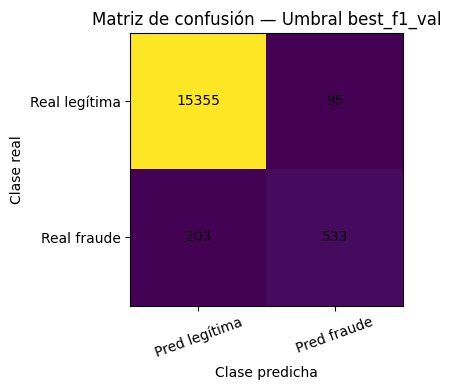

In [12]:
selected_name = "best_f1_val"
selected_threshold = thresholds[selected_name]
y_pred_selected = (test_proba >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_selected, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["Real legítima", "Real fraude"],
    columns=["Pred legítima", "Pred fraude"]
)
cm_df

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de confusión — Umbral best_f1_val")
plt.xticks([0, 1], ["Pred legítima", "Pred fraude"], rotation=20)
plt.yticks([0, 1], ["Real legítima", "Real fraude"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.tight_layout()
plt.show()


In [13]:
print(classification_report(
    y_test, y_pred_selected,
    target_names=["Legítima", "Fraude"],
    zero_division=0
))

              precision    recall  f1-score   support

    Legítima       0.99      0.99      0.99     15450
      Fraude       0.85      0.72      0.78       736

    accuracy                           0.98     16186
   macro avg       0.92      0.86      0.89     16186
weighted avg       0.98      0.98      0.98     16186



## 12. Curva ROC y curva Precision-Recall

La curva ROC resume la capacidad general de separación del modelo. La curva Precision-Recall es especialmente útil en fraude porque el dataset está desbalanceado.

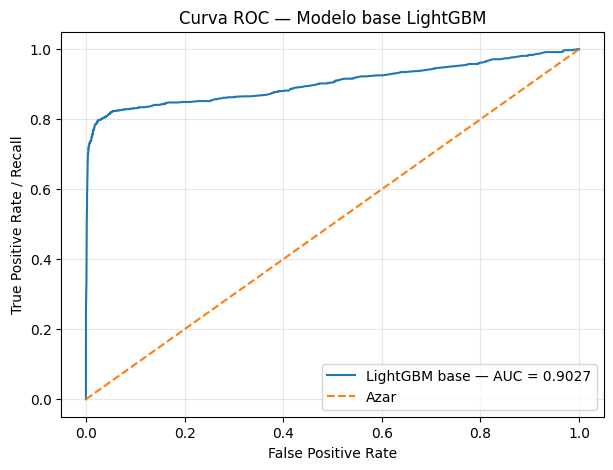

In [14]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_value = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LightGBM base — AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC — Modelo base LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

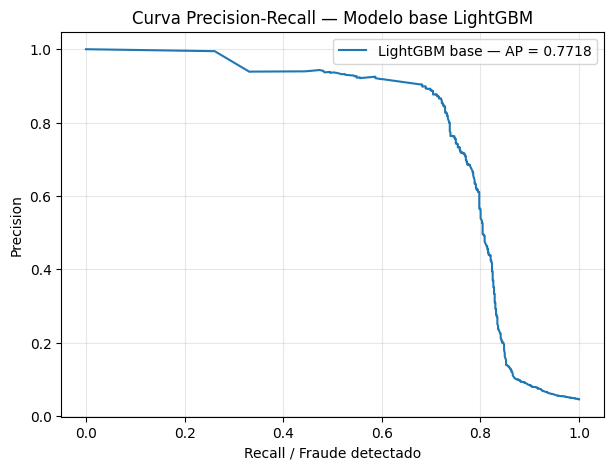

In [15]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)
ap_value = average_precision_score(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, label=f"LightGBM base — AP = {ap_value:.4f}")
plt.xlabel("Recall / Fraude detectado")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Modelo base LightGBM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Importancia de variables

Esta tabla permite revisar qué variables está utilizando más el modelo base. Es útil para validar si el modelo está aprovechando señales relacionadas con monto, distancia, tiempo, canal o comercio.

In [16]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": base_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv(RESULTS_DIR / "baseline_feature_importance.csv", index=False)
feature_importance.head(25)

,feature,importance
44,amount_baseline_ratio,93
14,DE18_merchant_category_code,89
1,channel,43
61,hours_since_last_txn,42
36,distance_from_home_km,38
62,is_rapid_succession,37
51,amount_vs_hist_avg,36
6,DE6_amount_cardholder_billing,29
5,DE4_amount_transaction,16
16,DE22_pos_entry_mode,14


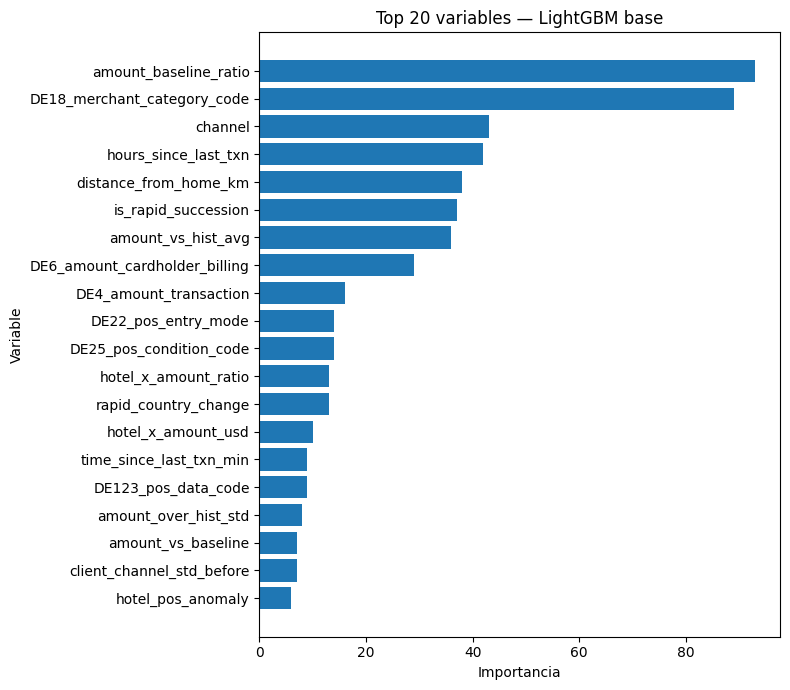

In [17]:
top_n = 20
plot_df = feature_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 7))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top {top_n} variables — LightGBM base")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 14. Guardar predicciones de junio

Se guarda un archivo con la probabilidad estimada de fraude y las predicciones binarias según el umbral seleccionado por F1. Este archivo sirve para auditoría y para comparar contra los modelos con métricas personalizadas.

In [18]:
predictions_june = pd.DataFrame({
    "transaction_id": test_df["transaction_id"].values if "transaction_id" in test_df.columns else np.arange(len(test_df)),
    "is_fraud_real": y_test.values.astype(bool),
    "fraud_probability_baseline": test_proba,
    "pred_baseline_best_f1": y_pred_selected.astype(bool),
    "selected_threshold": selected_threshold
})

predictions_june.to_csv(RESULTS_DIR / "baseline_predictions_june.csv", index=False)
predictions_june.head()

,transaction_id,is_fraud_real,fraud_probability_baseline,pred_baseline_best_f1,selected_threshold
0,7de5dc48-c098-4e31-adda-5816087a8627,False,0.178740,False,0.8688
1,3e381c38-0ecb-4b64-b466-a60374c67260,False,0.181021,False,0.8688
2,f1edee21-5b00-43d5-9f3a-fd6a6364a0b3,False,0.189239,False,0.8688
3,37453000-129f-4174-9c4c-f6c1ab06f75f,False,0.262373,False,0.8688
4,07cd9c21-37b4-4087-8156-a935314b7e46,False,0.156064,False,0.8688


## 15. Conclusión

El modelo base con LightGBM establece una primera referencia cuantitativa para la detección de fraude en transacciones de establecimientos de hospedaje. Esta etapa cumple con la consigna de entrenar un modelo inicial y evaluarlo mediante métricas tradicionales como **AUC-ROC** y **F1-score**, complementándolas con indicadores más operativos: fraude detectado, falsos positivos, falsos positivos por fraude detectado y proporción de falsos positivos dentro de las alertas.

La comparación entre umbrales muestra que el rendimiento no debe analizarse únicamente con AUC-ROC. En un problema desbalanceado como fraude, también es necesario revisar cuántas alertas falsas genera el modelo y qué porcentaje de fraudes reales logra detectar.